Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.preprocessing import RobustScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

Load Dataset & Inspect

In [2]:
df = pd.read_csv(
    "../datasets/processed/climate_anomalies.csv"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (119398, 149)


In [3]:
df["precip_mm"].describe()
print("\nTop 20 rainfall values:\n")

print(
    df["precip_mm"]
    .value_counts()
    .head(20)
)


Top 20 rainfall values:

precip_mm
0.00    104510
0.01      1551
0.10       900
0.02       862
0.03       585
0.20       476
0.04       469
0.05       414
0.06       333
0.30       300
0.08       291
0.07       287
0.40       268
0.50       228
0.09       227
0.12       189
0.60       186
0.70       170
0.13       160
0.11       160
Name: count, dtype: int64


In [4]:
print(df["precip_mm"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

0.50    0.00
0.75    0.00
0.90    0.03
0.95    0.33
0.99    1.91
Name: precip_mm, dtype: float64


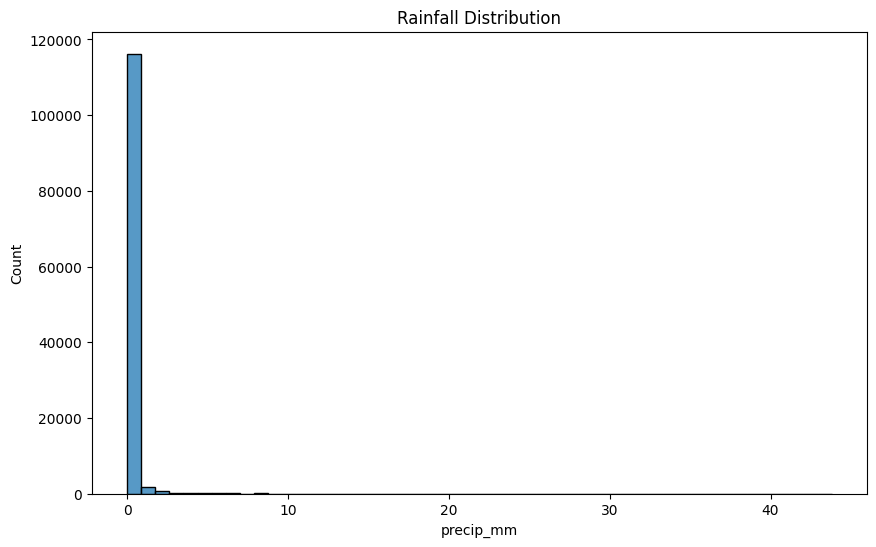

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(df["precip_mm"], bins=50)

plt.title("Rainfall Distribution")
plt.show()

Create Rainfall Risk Labels

In [6]:
def rainfall_risk(mm):

    if mm == 0:
        return "Low"

    elif mm <= 0.5:
        return "Medium"

    else:
        return "High"


df["rainfall_risk"] = df["precip_mm"].apply(rainfall_risk)

print(df["rainfall_risk"].value_counts())

C:\Users\ANAMIKA\AppData\Local\Temp\ipykernel_10800\2434668249.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rainfall_risk"] = df["precip_mm"].apply(rainfall_risk)


rainfall_risk
Low       104510
Medium     10223
High        4665
Name: count, dtype: int64


Visualize Classes

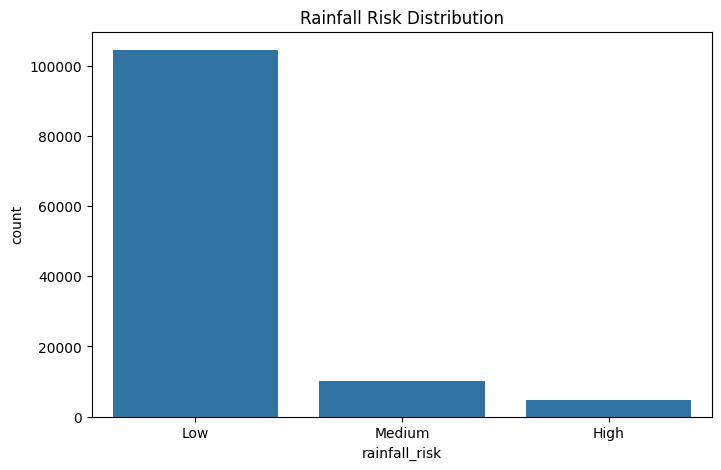

In [7]:
plt.figure(figsize=(8, 5))

sns.countplot(x="rainfall_risk", data=df)

plt.title("Rainfall Risk Distribution")

plt.show()

Feature Selection

In [8]:
drop_cols = ["precip_mm", "rainfall_risk"]

X = df.drop(columns=drop_cols)

y = df["rainfall_risk"]

print(X.shape)
print(y.shape)

(119398, 148)
(119398,)


Encode Target

In [9]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['High' 'Low' 'Medium']


One-Hot Encode Features

In [10]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(119398, 150)


Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(95518, 150)
(23880, 150)


Scale Features

In [12]:
rainfall_scaler = RobustScaler()

X_train_scaled = rainfall_scaler.fit_transform(X_train)

X_test_scaled = rainfall_scaler.transform(X_test)

joblib.dump(rainfall_scaler, "../models/rainfall_scaler.pkl")

print("Rainfall scaler saved")

Rainfall scaler saved


Baseline Model: Logistic Regression

In [13]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, log_preds))

print(classification_report(y_test, log_preds, target_names=label_encoder.classes_))

Accuracy: 0.9673366834170855
              precision    recall  f1-score   support

        High       0.88      0.80      0.84       933
         Low       0.98      1.00      0.99     20902
      Medium       0.86      0.76      0.80      2045

    accuracy                           0.97     23880
   macro avg       0.90      0.85      0.88     23880
weighted avg       0.97      0.97      0.97     23880



Strong Model : Random Forest

In [14]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_preds))

print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_))

Accuracy: 0.975
              precision    recall  f1-score   support

        High       0.88      0.82      0.85       933
         Low       0.99      1.00      0.99     20902
      Medium       0.90      0.82      0.86      2045

    accuracy                           0.97     23880
   macro avg       0.92      0.88      0.90     23880
weighted avg       0.97      0.97      0.97     23880



Hyperparameter Tuning

In [15]:
param_grid = {

    "n_estimators": [
        100,
        200,
        300,
        500
    ],

    "max_depth": [
        5,
        10,
        20,
        30,
        None
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

In [16]:
random_search = RandomizedSearchCV(

    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=param_grid,

    n_iter=20,

    cv=3,

    scoring="f1_weighted",

    verbose=2,

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

print(
    random_search.best_params_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [17]:
best_rf = random_search.best_estimator_

best_preds = best_rf.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        best_preds
    )
)

print(
    classification_report(
        y_test,
        best_preds,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.9752093802345059
              precision    recall  f1-score   support

        High       0.88      0.82      0.85       933
         Low       0.99      1.00      0.99     20902
      Medium       0.90      0.82      0.86      2045

    accuracy                           0.98     23880
   macro avg       0.92      0.88      0.90     23880
weighted avg       0.97      0.98      0.97     23880



Confusion Matrix

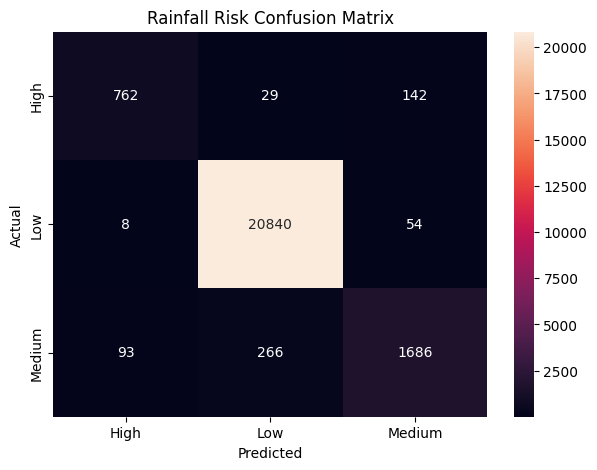

In [18]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)

plt.title("Rainfall Risk Confusion Matrix")

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

Feature Importance

In [19]:
importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": best_rf.feature_importances_}
)

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(20))

                        Feature  Importance
31   humidity_cloud_interaction    0.132574
7                         cloud    0.124739
108           condition_text_42    0.100695
145               anomaly_score    0.062511
77            condition_text_11    0.038072
107           condition_text_41    0.035089
28                pm_difference    0.029912
6                      humidity    0.029325
9                 visibility_km    0.025447
27              temperature_gap    0.019868
17             air_quality_PM10    0.017162
16            air_quality_PM2.5    0.016236
0                      latitude    0.014748
26           day_length_minutes    0.014465
8            feels_like_celsius    0.013931
5                   pressure_mb    0.013579
30    wind_humidity_interaction    0.013409
68             condition_text_2    0.013032
32               heatwave_index    0.012536
29          pollution_intensity    0.011983


Save Model

In [20]:
joblib.dump(best_rf, "../models/rainfall_risk_model.pkl")

joblib.dump(label_encoder, "../models/rainfall_label_encoder.pkl")

print("Rainfall model saved")

Rainfall model saved


Save Dataset

In [21]:
df.to_csv("../datasets/processed/rainfall_risk_dataset.csv", index=False)

print("Dataset saved successfully")

Dataset saved successfully


Verification

In [22]:
saved_df = pd.read_csv("../datasets/processed/rainfall_risk_dataset.csv")

print(saved_df.shape)

print(saved_df["rainfall_risk"].value_counts())

(119398, 150)
rainfall_risk
Low       104510
Medium     10223
High        4665
Name: count, dtype: int64


Report

In [23]:
print("""

RAINFALL RISK PREDICTION REPORT

Problem Type:
Multi-Class Classification

Algorithm:
Random Forest Classifier

Baseline:
Logistic Regression

Hyperparameter Tuning:
RandomizedSearchCV

Target Classes:
Low
Medium
High

Artifacts Saved:

rainfall_scaler.pkl

rainfall_risk_model.pkl

rainfall_label_encoder.pkl

rainfall_risk_dataset.csv

Completed Successfully

""")



RAINFALL RISK PREDICTION REPORT

Problem Type:
Multi-Class Classification

Algorithm:
Random Forest Classifier

Baseline:
Logistic Regression

Hyperparameter Tuning:
RandomizedSearchCV

Target Classes:
Low
Medium
High

Artifacts Saved:

rainfall_scaler.pkl

rainfall_risk_model.pkl

rainfall_label_encoder.pkl

rainfall_risk_dataset.csv

Completed Successfully


